In [1]:
from datasets.fsmol_dock import FsDockDataset
from datasets.partitioned_fsmol_dock import FsDockDatasetPartitioned
import torch
from Bio.PDB import PDBParser, DSSP, PPBuilder
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import os
import pandas as pd
from collections import defaultdict
import freesasa

/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alon.kitin/miniconda3/envs/FSdock/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
assays = ['CHEMBL1119333',
 'CHEMBL1614027',
 'CHEMBL1614423',
 'CHEMBL1963715',
 'CHEMBL1963723',
 'CHEMBL1963731',
 'CHEMBL1963741',
 'CHEMBL1963756',
 'CHEMBL1963810',
 'CHEMBL1963818',
 'CHEMBL1963819',
 'CHEMBL1963824',
 'CHEMBL1963825',
 'CHEMBL1963827',
 'CHEMBL1963831',
 'CHEMBL1964101',
 'CHEMBL1964115',
 'CHEMBL3214944',
 'CHEMBL3431930',
 'CHEMBL3431932']

tasks = pd.read_csv('/home/alon.kitin/fs-dock/data/fsdock/train_tasks.csv')
# tasks = tasks[tasks['assay_id'].isin(assays)]

In [88]:
success = dict(
    CHEMBL1119333=0.090772277,
CHEMBL1614027=0.018307637,
CHEMBL1614423=0.031414634,
CHEMBL1963715=0.002528233,
CHEMBL1963723=0.060623656,
CHEMBL1963731=0.039782609,
CHEMBL1963741=0.003069307,
CHEMBL1963756=-0.018965831,
CHEMBL1963810=0.008017442,
CHEMBL1963818=0.055373134,
CHEMBL1963819=0.001552743,
CHEMBL1963824=0.009649123,
CHEMBL1963825=0.051076923,
CHEMBL1963827=0.007576547,
CHEMBL1963831=0.087890295,
CHEMBL1964101=0.01854878,
CHEMBL1964115=0.075310881,
CHEMBL3214944=-0.009068966,
CHEMBL3431930=0.03220339,
CHEMBL3431932=0.013008734

)

In [3]:
pdb_files = tasks[['assay_id','protein_path']].drop_duplicates()

In [4]:
def extract_features_from_pdb(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    model = structure[0]

    # Extract sequence
    ppb = PPBuilder()
    sequence = "".join([str(pp.get_sequence()) for pp in ppb.build_peptides(model)])
    analysis = ProteinAnalysis(sequence)

    # General sequence features
    features = {}
    features["length"] = len(sequence)
    features["molecular_weight"] = analysis.molecular_weight()
    features["aromaticity"] = analysis.aromaticity()
    features["instability_index"] = analysis.instability_index()
    features["isoelectric_point"] = analysis.isoelectric_point()
    features["gravy"] = analysis.gravy()

    # Amino acid composition
    aa_composition = analysis.get_amino_acids_percent()
    for aa, perc in aa_composition.items():
        features[f"aa_{aa}"] = perc
    freesasa_struct = freesasa.Structure(pdb_file)
    features['sasa'] = freesasa.calc(freesasa_struct).totalArea()
    
    # DSSP for secondary structure content
    # try:
    #     dssp = DSSP(model, pdb_file)
    #     ss_counts = {"H": 0, "B": 0, "E": 0, "G": 0, "I": 0, "T": 0, "S": 0, "-": 0}
    #     for _, dssp_data in dssp.property_list:
    #         ss = dssp_data[2]
    #         ss_counts[ss] = ss_counts.get(ss, 0) + 1

    #     total_residues = sum(ss_counts.values())
    #     features["helix_content"] = (ss_counts["H"] + ss_counts["G"] + ss_counts["I"]) / total_residues
    #     features["sheet_content"] = (ss_counts["E"] + ss_counts["B"]) / total_residues
    #     features["coil_content"] = (ss_counts["T"] + ss_counts["S"] + ss_counts["-"]) / total_residues
    # except Exception as e:
    #     print("DSSP failed:", e)

    # # Ligand-binding site: count of residues within 5 Å of ligand atoms
    # ligand_atoms = [atom for atom in model.get_atoms() if atom.get_parent().id[0].startswith("H_")]
    # binding_residues = set()
    # for chain in model:
    #     for residue in chain:
    #         if residue.id[0] == " ":
    #             for atom in residue:
    #                 for ligand_atom in ligand_atoms:
    #                     distance = atom - ligand_atom
    #                     if distance < 5.0:
    #                         binding_residues.add(residue)
    #                         break
    # features["binding_site_residue_count"] = len(binding_residues)

    return features

In [5]:
features = {}
for task in pdb_files.iterrows():
    task= task[1]
    features[task['assay_id']] = extract_features_from_pdb(task['protein_path'])
    # features[task['assay_id']]['label'] = success[task['assay_id']]
features_df = pd.DataFrame.from_dict(features, orient='index')

In [8]:
features_df['gravy'].describe([0.1,0.2,0.8,0.9])

count    4250.000000
mean       -0.185767
std         0.367824
min        -1.290458
10%        -0.578846
20%        -0.469548
50%        -0.262971
80%         0.102965
90%         0.419972
max         0.935294
Name: gravy, dtype: float64

<Axes: >

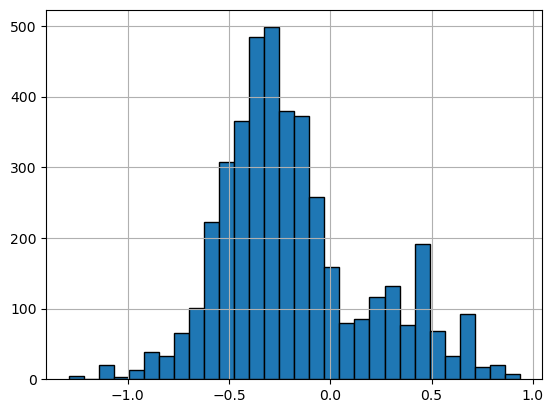

In [6]:
features_df['gravy'].hist(bins=30, edgecolor='black')

In [92]:
X = features_df[['length', 'molecular_weight', 'aromaticity', 'instability_index',
       'isoelectric_point', 'gravy', 'aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F',
       'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L', 'aa_M', 'aa_N', 'aa_P', 'aa_Q',
       'aa_R', 'aa_S', 'aa_T', 'aa_V', 'aa_W', 'aa_Y',
       'binding_site_residue_count']]
X = features_df[['length', 'molecular_weight', 'aromaticity', 'instability_index',
       'isoelectric_point', 'gravy']]

y = features_df['label']

In [122]:
structure = freesasa.Structure("/home/alon.kitin/docking_cfom/data/proteins/pdbs/P22303.pdb")
result = freesasa.calc(structure)
area_classes = freesasa.classifyResults(result, structure)

print("Total : %.2f A2" % result.totalArea())
for key in area_classes:
    print(key, ": %.2f A2" % area_classes[key])

Total : 29026.73 A2
Polar : 12143.74 A2
Apolar : 16882.98 A2


In [97]:

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=1
                             )
y_binary = [1 if i > 0.01 else 0 for i in y]    
clf.fit(X,y_binary)

DecisionTreeClassifier(max_depth=1)

In [98]:
clf.score(X,y_binary)

0.75

In [99]:
clf.feature_importances_

array([0., 0., 0., 0., 0., 1.])

In [100]:
clf.predict(X) 

array([1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1])

In [85]:
np.array(features_df['label'])

array([1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1])

In [125]:
features_df.corr()['label'].abs().sort_values(ascending=False)

label                1.000000
aa_L                 0.644782
aa_K                 0.575820
aa_A                 0.550375
aa_S                 0.523344
gravy                0.510986
aa_I                 0.501612
aa_W                 0.472211
aa_P                 0.465574
aa_T                 0.428914
aa_V                 0.411361
aa_G                 0.409366
sasa                 0.406460
aa_N                 0.379231
molecular_weight     0.368211
length               0.351051
isoelectric_point    0.278773
aa_M                 0.274779
aa_D                 0.218150
instability_index    0.212457
aa_E                 0.196492
aromaticity          0.194354
aa_H                 0.113995
aa_F                 0.083827
aa_Q                 0.071421
aa_C                 0.054777
aa_Y                 0.016241
aa_R                 0.015697
Name: label, dtype: float64

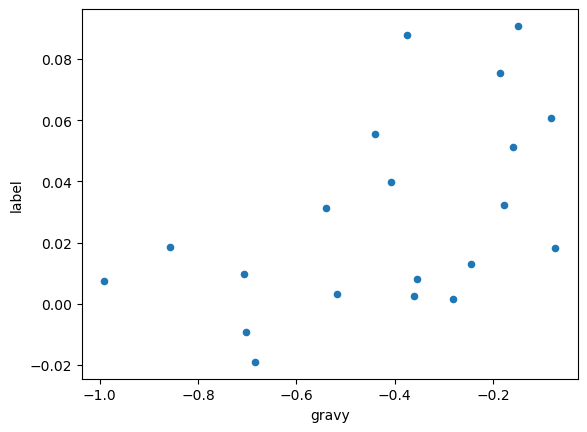

In [111]:
def plot(name):
    features_df[[name,'label']].plot.scatter(x=name,y='label')

plot('gravy')

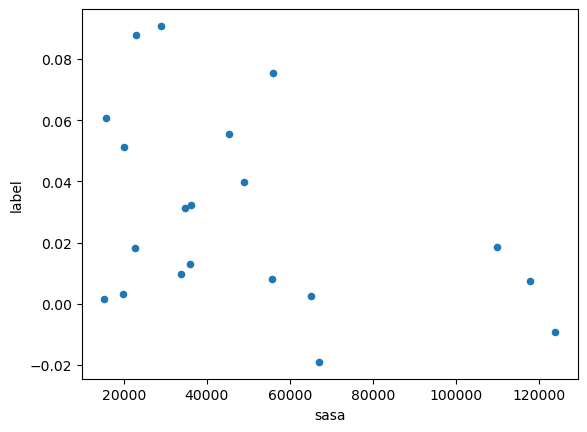

In [126]:
plot('sasa')

In [118]:
import freesasa

In [117]:
! pip install freesasa

  Preparing metadata (setup.py) ... done
  Created wheel for freesasa: filename=freesasa-2.2.1-cp39-cp39-linux_x86_64.whl size=325565 sha256=8e174224886a6d72b0ae3bac27f35863106b0cdc179fb65d202b1c87ff88c8c3
  Stored in directory: /home/alon.kitin/.cache/pip/wheels/cd/f0/b5/1b158a3b1fba5bf481e7af23a8c7479146296531f22f7fee67
Successfully built freesasa
